# Lab Instructions

You have been hired by a record executive to design a guaranteed smash hit song based on data.  The exec has decided that if you make a song that has all the most popular features of recent songs then it will definitely be a hit.  So if - for example - the most common key in the Spotify data is C# then we would want the song we are designing to also be in C#.  If a "typical" value of BPM is between 120 and 130 then we would want the song we are designing to also have a tempo between 120 and 130 BMP.

Visualize and describe the distribution of:
* BPM
* Key
* Mode
* Danceability
* Energy
* Speechiness
* Acousticness

Based on your visualizations and calculations, what values for each of these features would make a song a guaranteed smash hit?  For quantitative features, you should propose a range of values.

Use a large language model to help you write code to identify if there are any songs in the Spotify dataset that meet all of the criteria we determined.  What is/are the artist(s) and title(s) of the song?  Were any of these songs actually popular?

Pick a song that you know was a smash hit. How do the values of BPM, key, mode, danceability, etc. compare to other songs? 

**Hint:**  Import the Spotify data using `df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')`.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('spotify-2023.csv' , encoding='ISO-8859-1')

df.head

<bound method NDFrame.head of                               track_name      artist(s)_name  artist_count  \
0    Seven (feat. Latto) (Explicit Ver.)    Latto, Jung Kook             2   
1                                   LALA         Myke Towers             1   
2                                vampire      Olivia Rodrigo             1   
3                           Cruel Summer        Taylor Swift             1   
4                         WHERE SHE GOES           Bad Bunny             1   
..                                   ...                 ...           ...   
948                         My Mind & Me        Selena Gomez             1   
949            Bigger Than The Whole Sky        Taylor Swift             1   
950                 A Veces (feat. Feid)  Feid, Paulo Londra             2   
951                        En La De Ella  Feid, Sech, Jhayco             3   
952                                Alone           Burna Boy             1   

     released_year  released_mont

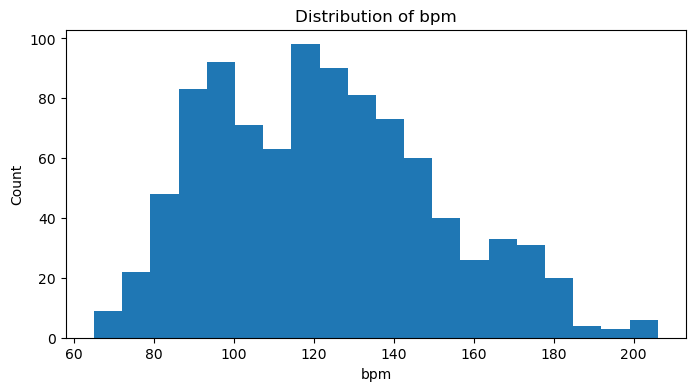

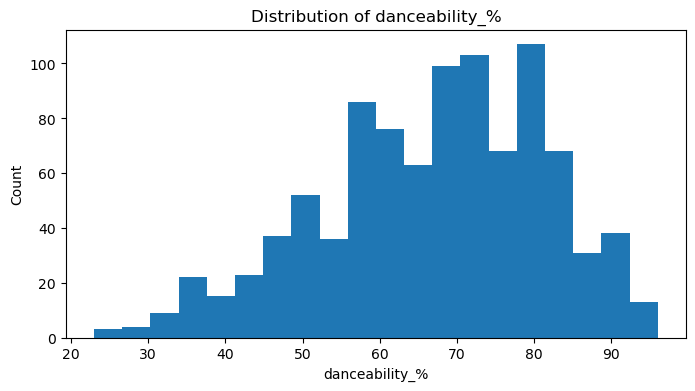

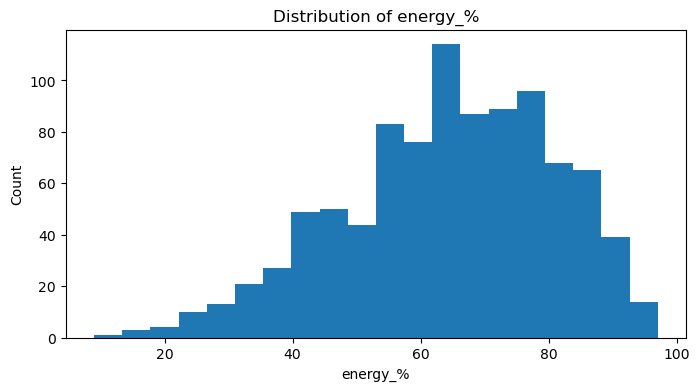

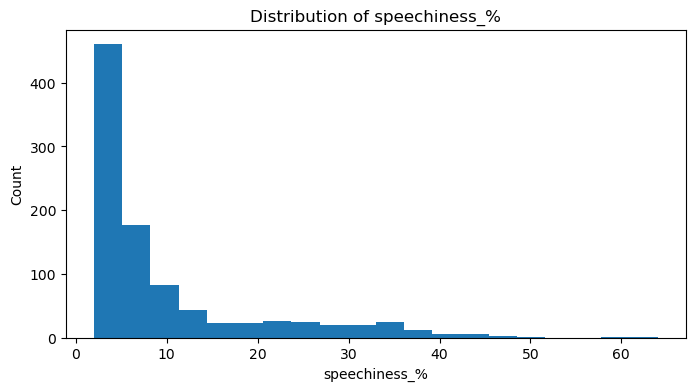

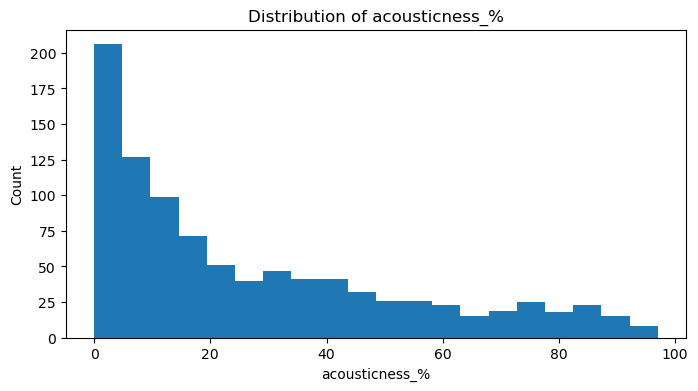

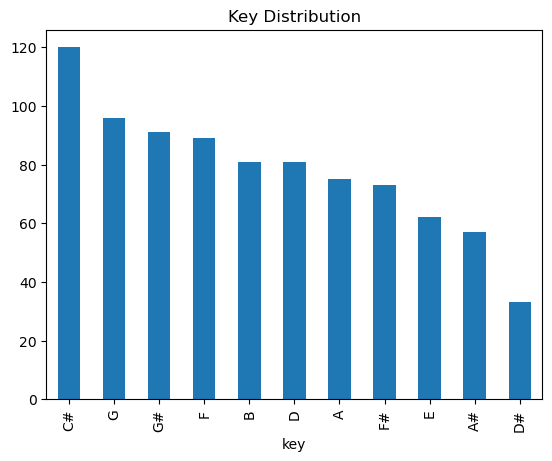

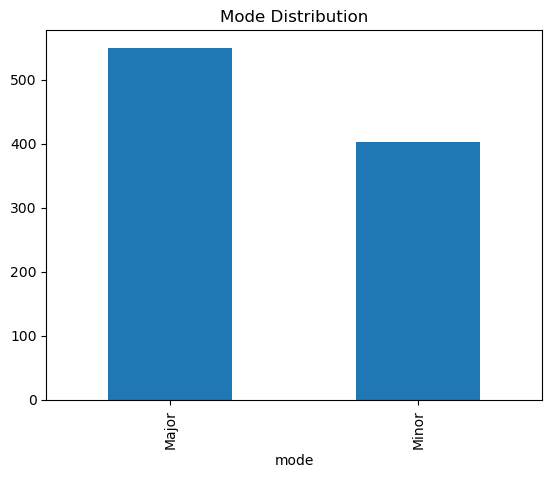

In [11]:
features = [
    'bpm',
    'danceability_%',
    'energy_%',
    'speechiness_%',
    'acousticness_%'
]

for col in features:
    plt.figure(figsize=(8,4))
    plt.hist(df[col], bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

df['key'].value_counts().plot(kind='bar', title='Key Distribution')
plt.show()

df['mode'].value_counts().plot(kind='bar', title='Mode Distribution')
plt.show()

In [14]:
most_common_key = df['key'].mode()[0]
most_common_mode = df['mode'].mode()[0]

bpm_low, bpm_high = df['bpm'].quantile(.25), df['bpm'].quantile(.75)
dance_low, dance_high = df['danceability_%'].quantile(.25), df['danceability_%'].quantile(.75)
energy_low, energy_high = df['energy_%'].quantile(.25), df['energy_%'].quantile(.75)
speech_low, speech_high = df['speechiness_%'].quantile(.25), df['speechiness_%'].quantile(.75)
acoustic_low, acoustic_high = df['acousticness_%'].quantile(.25), df['acousticness_%'].quantile(.75)

print("Most Common Key:", most_common_key)
print("Most Common Mode:", most_common_mode)

print("\nSmash Hit Formula")
print("BPM:", bpm_low, "-", bpm_high)
print("Danceability:", dance_low, "-", dance_high)
print("Energy:", energy_low, "-", energy_high)
print("Speechiness:", speech_low, "-", speech_high)
print("Acousticness:", acoustic_low, "-", acoustic_high)

smash_hits = df[
    (df['bpm'].between(bpm_low, bpm_high)) &
    (df['danceability_%'].between(dance_low, dance_high)) &
    (df['energy_%'].between(energy_low, energy_high)) &
    (df['speechiness_%'].between(speech_low, speech_high)) &
    (df['acousticness_%'].between(acoustic_low, acoustic_high)) &
    (df['key'] == most_common_key) &
    (df['mode'] == most_common_mode)
]

print("\nMatching Songs:", len(smash_hits))

smash_hits[['track_name','artist(s)_name','streams']]

Most Common Key: C#
Most Common Mode: Major

Smash Hit Formula
BPM: 100.0 - 140.0
Danceability: 57.0 - 78.0
Energy: 53.0 - 77.0
Speechiness: 4.0 - 11.0
Acousticness: 6.0 - 43.0

Matching Songs: 2


,track_name,artist(s)_name,streams
518,Need To Know,Doja Cat,1042568408
660,Ginseng Strip 2002,Yung Lean,240769997


In [15]:
stay = df[df['track_name'].str.contains(
    'STAY',
    case=False,
    na=False
)]

stay[['track_name',
      'artist(s)_name',
      'streams',
      'bpm',
      'key',
      'mode',
      'danceability_%',
      'energy_%',
      'speechiness_%',
      'acousticness_%']]

,track_name,artist(s)_name,streams,bpm,key,mode,danceability_%,energy_%,speechiness_%,acousticness_%
84,STAY (with Justin Bieber),"Justin Bieber, The Kid Laroi",2665343922,170,C#,Major,59,76,5,4
650,Stay Alive (Prod. SUGA of BTS),Jung Kook,246376690,130,D,Minor,51,76,7,30
883,STAYING ALIVE (feat. Drake & Lil Baby),"Drake, DJ Khaled, Lil Baby",170732845,130,E,Minor,72,46,8,7
894,"Stay With Me (with Justin Timberlake, Halsey, ...","Calvin Harris, Halsey, Pharrell Williams, Just...",123473120,126,A,Major,81,73,4,28
927,I Really Want to Stay at Your House,"Rosa Walton, Hallie Coggins",140430339,125,D#,Minor,49,74,4,0
